## Imports

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

---
## Fonction de simulation

In [31]:
all_dfs = []

# Parameters
E=1
rho=2
L=1
Nt=300
Nx=100
t_end=3

ndt=1
N=6

nodes = np.arange(1, Nx-1)          # nœuds intérieurs (remplace for j in range(1, Nx-1))

AMPLITUDES = np.linspace(0.005, 0.1, N).round(3).tolist()
PULSATIONS = np.linspace(7, 90, N).round(1).tolist()
n_sims = len(AMPLITUDES)*len(PULSATIONS)

# We compute each simulation
for idx, (A, omega) in enumerate(product(AMPLITUDES, PULSATIONS), start=1):
    v = np.sqrt(E/rho)    # vitesse des ondes [m/s]

    # Grille
    x  = np.linspace(0, L, Nx)
    dx = x[1] - x[0]
    dt = t_end / Nt

    # Stable behaviour
    CFL = v * dt / dx
    assert CFL <= 1.0, f"CFL={CFL:.3f} > 1 : schéma instable"

    # Conditions aux limites
    t_pulse = 2 * np.pi / omega

    def u_right(t):
        if t < t_pulse:
            return A * np.sin(omega * t)
        else:
            return 0.0

    u     = np.zeros(Nx)
    u_2   = np.zeros(Nx)

    u_storage       = np.zeros((Nt+1, Nx))
    u_xx_storage    = np.zeros((Nt, Nx))
    delta_u_storage = np.zeros((Nt, Nx))

    u_storage[0] = u.copy()

    rows = []

    for n in range(Nt):
        tn = n * dt

        u_xx = np.zeros(Nx)
        u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2

        u_new = np.zeros(Nx)
        u_new[1:-1] = 2*u[1:-1] - u_2[1:-1] + CFL**2 * (u[2:] - 2*u[1:-1] + u[:-2])

        # Conditions aux limites
        u_new[0]  = 0
        u_new[-1] = u_right(tn + dt)


        u_xx_storage[n]    = u_xx
        delta_u_storage[n] = u_new - u

        u_2 = u.copy()
        u   = u_new
        u_storage[n + 1] = u.copy()

    # Après la boucle : construction du dataset avec u_dot coarse (vectorisée sur les nœuds)
    for n in range(ndt, Nt-ndt-1):
        u_dot_coarse = (u_storage[n] - u_storage[n-ndt]) / (ndt * dt)
        rows.append(pd.DataFrame({
            "A":       A,
            "omega":   omega,
            "u_dot":   u_dot_coarse[nodes],
            "u_xx":    u_xx_storage[n, nodes],
            "delta_u": u_storage[n+ndt, nodes] - u_storage[n, nodes],
        }))

    all_dfs.append(pd.concat(rows, ignore_index=True))

# We concatenate each simulation in the df which is the full dataset table
df = pd.concat(all_dfs, ignore_index=True)
print(df.head(0))

Empty DataFrame
Columns: [A, omega, u_dot, u_xx, delta_u]
Index: []



## Split train / val / test

In [32]:
rng = np.random.default_rng(seed=42)

combos     = list(product(AMPLITUDES, PULSATIONS))
combos_arr = rng.permutation(combos)

n_train = int(0.70 * n_sims)
n_val   = int(0.15 * n_sims)

train_combos = set(map(tuple, combos_arr[:n_train]))
val_combos   = set(map(tuple, combos_arr[n_train:n_train + n_val]))
test_combos  = set(map(tuple, combos_arr[n_train + n_val:]))

def assign_split(row):
    key = (row["A"], row["omega"])
    if key in train_combos: return "train"
    if key in val_combos:   return "val"
    return "test"

df["split"] = df.apply(assign_split, axis=1)

print("Distribution du split :")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:5s} : {n:>8,} lignes  ({100*n/len(df):.1f} %)")


Distribution du split :
  train :  727,650 lignes  (69.4 %)
  val   :  145,530 lignes  (13.9 %)
  test  :  174,636 lignes  (16.7 %)


## Normalisation (z-score)

In [33]:
INPUTS  = ["u_dot","u_xx"]
OUTPUTS = ["delta_u"]

# Masque train pour calculer les stats uniquement sur le train set
train_mask = df["split"] == "train"

# Calcul des stats sur le train set uniquement
norm_stats = pd.DataFrame({
    "mean": df.loc[train_mask, INPUTS + OUTPUTS].mean(),
    "std" : df.loc[train_mask, INPUTS + OUTPUTS].std(),
})
norm_stats["std"] = norm_stats["std"].replace(0, 1)  # éviter division par 0

# Application à tout le dataset
for col in INPUTS + OUTPUTS:
    df[col + "_n"] = (df[col] - norm_stats.loc[col, "mean"]) / norm_stats.loc[col, "std"]

print("Statistiques de normalisation (calculées sur train) :")
print(norm_stats.round(6))

Statistiques de normalisation (calculées sur train) :
             mean        std
u_dot    0.000626   0.583773
u_xx    -0.007950  86.127196
delta_u  0.000006   0.005848


---
## Sauvegarde

In [34]:
COLS_ORDER = (
    INPUTS                                   # inputs bruts
    + [c + "_n" for c in INPUTS]             # inputs normalisés
    + OUTPUTS                                # outputs bruts
    + [c + "_n" for c in OUTPUTS]            # outputs normalisés
    + ["split"]
)
df = df[COLS_ORDER]

# Dataset
df.to_csv("wave_beam_dataset.csv", index=False)
print(f"Dataset sauvegardé : wave_beam_dataset.csv")
print(f"  {len(df):,} lignes × {len(df.columns)} colonnes")

# Stats de normalisation — à recharger dans les fichiers 2 et 3
norm_stats.to_csv("norm_stats.csv")
print(f"Stats de normalisation sauvegardées : norm_stats.csv")

Dataset sauvegardé : wave_beam_dataset.csv
  1,047,816 lignes × 7 colonnes
Stats de normalisation sauvegardées : norm_stats.csv


In [35]:
import json

params_simulation = {
    "L"          : L,
    "Nx"         : Nx,
    "Nt"         : Nt,
    "t_end"      : t_end,
    "E": E,
    "rho":rho,
    "AMPLITUDES" : AMPLITUDES,
    "PULSATIONS" : PULSATIONS,
    "n_sims"     : n_sims,
    "INPUTS":INPUTS,
    "OUTPUTS":OUTPUTS,
}

with open("params_simulation.json", "w") as f:
    json.dump(params_simulation, f, indent=2)

print("Paramètres sauvegardés : params_simulation.json")

Paramètres sauvegardés : params_simulation.json


# 02 — Entraînement du réseau


In [36]:
import numpy as np
import json

with open("params_simulation.json") as f:
    p = json.load(f)

L, Nx, Nt,t_end  = p["L"], p["Nx"], p["Nt"], p["t_end"]
AMPLITUDES    = p["AMPLITUDES"]
PULSATIONS    = p["PULSATIONS"]
n_sims        = p["n_sims"]
INPUTS=p["INPUTS"]
OUTPUTS=p["OUTPUTS"]
E   = p["E"]
rho = p["rho"]
v   = np.sqrt(E / rho)

---
## 1. Paramètres

In [37]:
# Fichiers produits par le notebook 01
DATASET_FILE   = "wave_beam_dataset.csv"
NORMSTATS_FILE = "norm_stats.csv"

# Architecture du réseau
HIDDEN_SIZE =  50   # nombre de neurones par couche cachée
N_LAYERS    = 3     # nombre de couches cachées

# Entraînement
LEARNING_RATE = 1e-3
N_EPOCHS      = 10
BATCH_SIZE    = 512

---
## 2. Chargement des données

In [38]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Chargement du dataset et des stats de normalisation
df         = pd.read_csv(DATASET_FILE)
norm_stats = pd.read_csv(NORMSTATS_FILE, index_col=0)

#To check and visualise
print(f"Dataset : {len(df):,} lignes")
print(f"Splits  : {df['split'].value_counts().to_dict()}")

# Colonnes normalisées
INPUTS_N  = ["u_dot_n","u_xx_n"]
OUTPUTS_N = ["delta_u_n"]

# Extraction train / val en utilisant la colonne split du dataset
train_mask = df["split"] == "train"
val_mask   = df["split"] == "val"

X_train = df.loc[train_mask, INPUTS_N].values.astype(np.float32)
y_train = df.loc[train_mask, OUTPUTS_N].values.astype(np.float32)

X_val   = df.loc[val_mask, INPUTS_N].values.astype(np.float32)
y_val   = df.loc[val_mask, OUTPUTS_N].values.astype(np.float32)

print(f"\nTrain : {len(X_train):,} exemples")
print(f"Val   : {len(X_val):,} exemples")

# Conversion en tenseurs PyTorch et création des DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=BATCH_SIZE
)

Dataset : 1,047,816 lignes
Splits  : {'train': 727650, 'test': 174636, 'val': 145530}

Train : 727,650 exemples
Val   : 145,530 exemples


---
## 3. Network definition


In [39]:
class Reseau(nn.Module):

    def __init__(self, n_inputs, n_outputs, hidden_size, n_layers):
        super().__init__()

        couches = []
        taille_entree = n_inputs

        for _ in range(n_layers):
            couches.append(nn.Linear(taille_entree, hidden_size,bias=False))  # couche linéaire
            couches.append(nn.Tanh())                              # activation non-linéaire
            taille_entree = hidden_size

        couches.append(nn.Linear(hidden_size, n_outputs, bias=False))  # couche de sortie

        self.reseau = nn.Sequential(*couches)

    def forward(self, x):
        return self.reseau(x)


modele = Reseau(
    n_inputs    = len(INPUTS_N), 
    n_outputs   = len(OUTPUTS_N),   
    hidden_size = HIDDEN_SIZE,
    n_layers    = N_LAYERS,
)

n_params = sum(p.numel() for p in modele.parameters())
print(modele)
print(f"\nNombre de paramètres : {n_params:,}")

Reseau(
  (reseau): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=False)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=50, bias=False)
    (3): Tanh()
    (4): Linear(in_features=50, out_features=50, bias=False)
    (5): Tanh()
    (6): Linear(in_features=50, out_features=1, bias=False)
  )
)

Nombre de paramètres : 5,150


---
## 4. Training

Epoch    2/10  —  train: 0.0005  |  val: 0.0001  
Epoch    4/10  —  train: 0.0002  |  val: 0.0000  
Epoch    6/10  —  train: 0.0002  |  val: 0.0000  
Epoch    8/10  —  train: 0.0001  |  val: 0.0001  
Epoch   10/10  —  train: 0.0001  |  val: 0.0001  


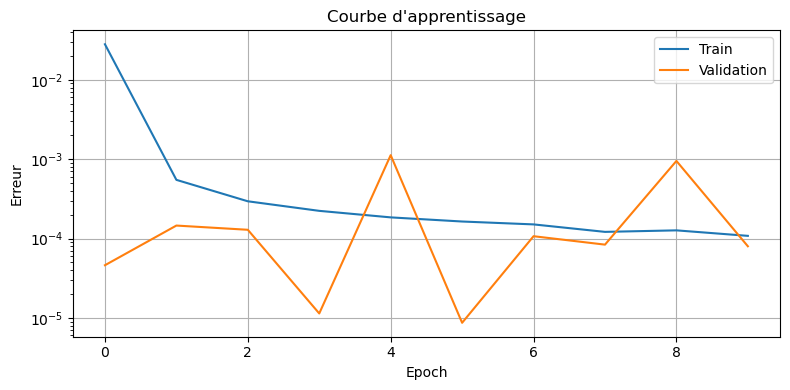

Meilleur modèle rechargé — val minimale : 0.000009


In [40]:
def mape (prediction, cible,eps=1e-8):
        num=torch.abs(cible-prediction)*2
        den=torch.abs(cible)+torch.abs(prediction)+eps
        return (num/den).mean()

#criterion  = mape
criterion = nn.MSELoss()
#criterion = nn.HuberLoss(delta=1.0)
#criterion = nn.L1Loss()


optimiseur = torch.optim.Adam(modele.parameters(), lr=LEARNING_RATE)    

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiseur, mode="min", factor=0.5, patience=10)

historique_train = []
historique_val   = []

meilleure_val = float("inf")  

for epoch in range(1, N_EPOCHS + 1):

    #Training
    modele.train()

    perte_train = 0.0       #initialisation of training loss

    for X_batch, y_batch in train_loader:
        optimiseur.zero_grad()                       # remet les gradients à zéro

        prediction = modele(X_batch)                 # prédiction

        perte      =    criterion(prediction, y_batch)  # erreur

        perte.backward()                             # rétropropagation

        optimiseur.step()                            # mise à jour des poids

        perte_train += perte.item()

    perte_train /= len(train_loader)

    # Phase validation
    modele.eval()
    
    with torch.no_grad():
        pred_val = modele(torch.as_tensor(X_val, dtype=torch.float32)) 
        perte_val = criterion(pred_val, torch.as_tensor(y_val, dtype=torch.float32)).item()
    
    scheduler.step(perte_val)

    # Loss par output
    historique_train.append(perte_train)
    historique_val  .append(perte_val)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:4d}/{N_EPOCHS}  —  "
            f"train: {perte_train:.4f}  |  "
            f"val: {perte_val:.4f}  ")
    
    # Si la val s'est améliorée, on sauvegarde ce modèle
    if perte_val < meilleure_val:

        meilleure_val = perte_val

        torch.save(modele.state_dict(), "model.pth")   # on écrase avec le meilleur

# Courbe d'apprentissage
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(historique_train, label="Train")
ax.plot(historique_val,   label="Validation")
ax.set_xlabel("Epoch") ; ax.set_ylabel("Erreur")
ax.set_title("Courbe d'apprentissage")
ax.set_yscale("log")
ax.legend() ; ax.grid(True)
plt.tight_layout() ; plt.show()

# On recharge le meilleur modèle trouvé pendant l'entraînement

modele.load_state_dict(torch.load("model.pth",weights_only=True ))

print(f"Meilleur modèle rechargé — val minimale : {meilleure_val:.6f}")

---
## Vérification

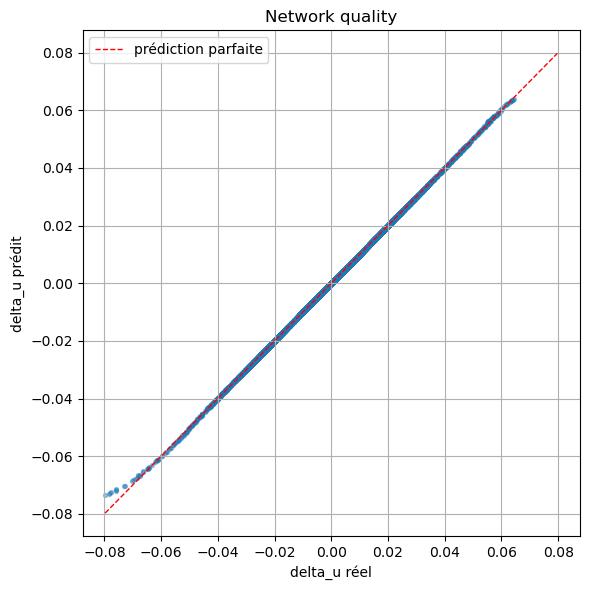

MSE : 1.5151e-09   |   R² : 0.9999


In [41]:
# On met le réseau en mode évaluation (désactive le dropout si on en avait)
# En mode eval, les poids sont figés — le réseau ne s'entraîne plus
df_test=df[df["split"]=="test"].reset_index(drop=True)

X_new  = df_test[INPUTS_N].values.astype(np.float32)
y_true = df_test[OUTPUTS].values   # shape (N, 3)

modele.eval()
with torch.no_grad():
    y_pred_n = modele(torch.tensor(X_new)).numpy()   # shape (N, 3)


# Dénormalisation colonne par colonne
y_pred = np.zeros_like(y_pred_n)
for i, col in enumerate(OUTPUTS):
    mean_du = norm_stats.loc[col, "mean"]
    std_du  = norm_stats.loc[col, "std"]
    y_pred[:, i] = y_pred_n[:, i] * std_du + mean_du
    
idx = 0                  # ← index de la sortie à tracer (0, 1 ou 2 selon OUTPUTS)
u_reel = y_true[:, idx]  # valeurs réelles dénormalisées
u_pred = y_pred[:, idx]  # valeurs prédites dénormalisées

# --- Graphiques "valeur prédite vs valeur réelle" ---
fig, ax = plt.subplots(figsize=(6, 6)) 

ax.scatter(u_reel, u_pred, alpha=0.4, s=8)
# Ligne rouge diagonale = prédiction parfaite
# Si le réseau était parfait, tous les points seraient sur cette ligne
lim = max(abs(u_reel).max(), abs(u_pred).max())   # échelle symétrique autour de 0

ax.plot([-lim, lim], [-lim, lim], "r--", lw=1, label="prédiction parfaite")

ax.set_xlabel("delta_u réel")
ax.set_ylabel("delta_u prédit")
ax.set_title("Network quality")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


# Métriques utiles
mse = ((u_pred - u_reel)**2).mean()
r2  = 1 - mse / u_reel.var()
print(f"MSE : {mse:.4e}   |   R² : {r2:.4f}")

0.0014505830004054587
0.048001209001085954


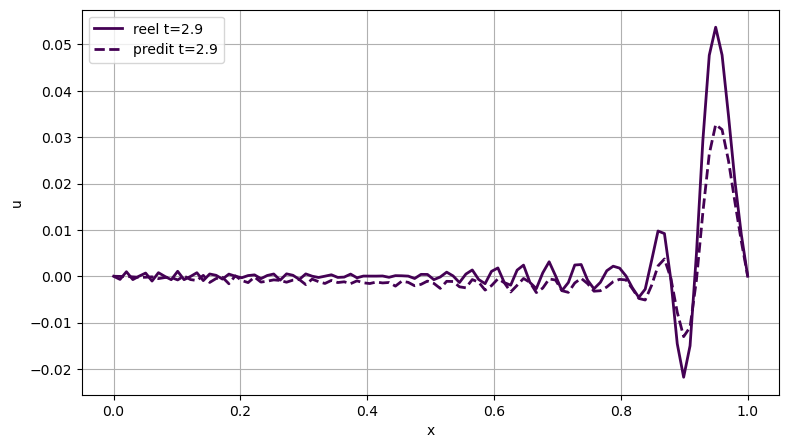

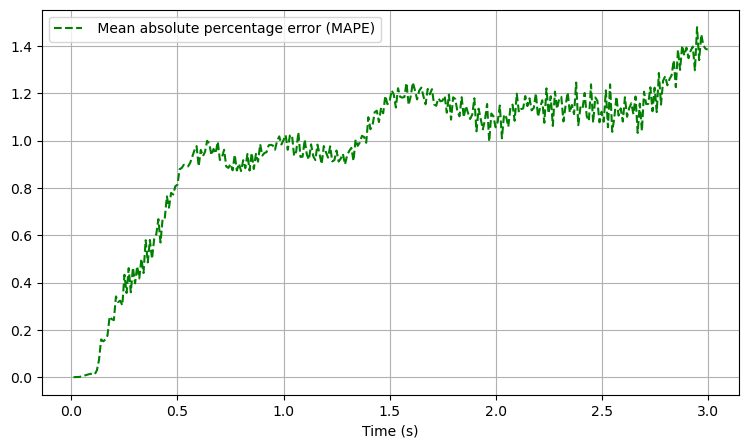

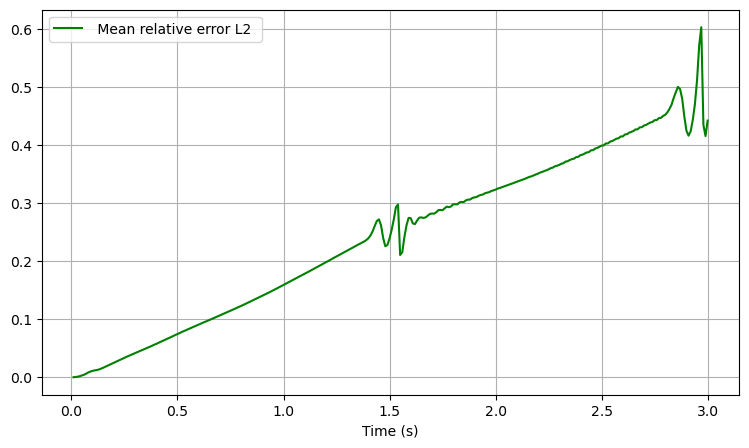

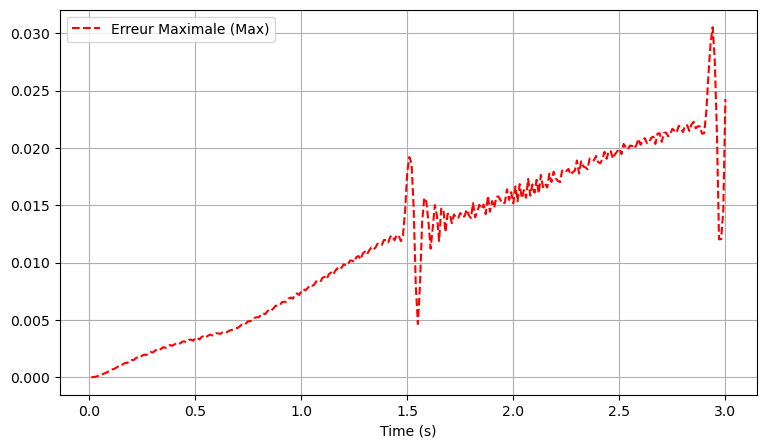

In [42]:
import time

##Cell hard coded for this particular situation

A = AMPLITUDES[2]
omega = PULSATIONS[2]
dx = L / (Nx - 1)
dt = t_end / Nt
#t_list = [0.5, 0.9, 1.5]
t_list = [2.9]
#t_list = [9.9]
x = np.linspace(0, L, Nx)

stats_normalisation = {}
for name in INPUTS + OUTPUTS:
    stats_normalisation[name] = {
        "mean": norm_stats.loc[name, "mean"],
        "std" : norm_stats.loc[name, "std"]
    }

# Stats de la sortie (delta_u)
mu_du = stats_normalisation[OUTPUTS[0]]["mean"]
sd_du = stats_normalisation[OUTPUTS[0]]["std"]

t_pulse = 2 * np.pi / omega
def u_right(t):
    if t < t_pulse:
        return A * np.sin(omega * t)
    else:
        return 0.0

# =====================================================
# 1) VRAIE simulation : schema centre (la physique)
# =====================================================

start_time_phys = time.perf_counter()

v = np.sqrt(E / rho)
CFL = v * dt / dx

u   = np.zeros(Nx)      # etat courant   u^n
u_2 = np.zeros(Nx)      # etat precedent u^{n-1}
reel = {0.0: u.copy()}

for n in range(Nt):
    t = n * dt
    t_suivant=round((n+1)*dt, 5)

    u_new = np.zeros(Nx)
    u_new[1:-1] = 2*u[1:-1] - u_2[1:-1] + CFL**2 * (u[2:] - 2*u[1:-1] + u[:-2])
    u_new[0]  = 0.0
    u_new[-1] = u_right(t+dt)

    u_2 = u.copy()
    u   = u_new

    reel[t_suivant] = u.copy()

time_phys = time.perf_counter() - start_time_phys

# =====================================================
# 2) Simulation PREDITE : on remplace la physique par le reseau
# =====================================================

start_time_pred = time.perf_counter()

u   = np.zeros(Nx)      # etat courant   u^n
u_ndt = np.zeros(Nx)      # etat precedent u^{n-1}
pred = {0.0: u.copy()}



# Noms bruts associes a chaque colonne, dans l'ordre vu a l'entrainement (INPUTS_N)
noms_features = [c[:-2] for c in INPUTS_N]   # "u_xx_n" -> "u_xx", etc.

# Entree au repos (u = u_xx = u_dot = 0), meme ordre de colonnes que INPUTS_N
entree_repos = np.zeros((Nx, len(INPUTS_N)), dtype=np.float32)
for idx, name in enumerate(noms_features):
    mu = stats_normalisation[name]["mean"]
    sd = stats_normalisation[name]["std"]
    entree_repos[:, idx] = (0.0 - mu) / sd

# with torch.no_grad():
#     sortie_repos = modele(torch.tensor(entree_repos)).numpy().ravel()
# bias_repos = sortie_repos * sd_du + mu_du

temps_sim=np.zeros(Nt)

# Error initialisation

error_mape=np.zeros(Nt)
error_max=np.zeros(Nt)
error_l2_rel=np.zeros(Nt)

def l2_rel(u_pred, u_reel, eps=1e-12):
    num = np.linalg.norm(u_pred - u_reel)
    den = (np.linalg.norm(u_reel) + eps)
    return  num / den 

def smape (prediction, cible,eps=1e-12):
    mask = cible!= 0
    num=np.abs(cible[mask]-prediction[mask])*2
    den=np.abs(cible[mask]) +np.abs(prediction[mask])
    return np.mean((num/den))

def errormax(cible, prediction,eps=1e-12):
    num = np.abs(cible-prediction)
    #den = np.abs(cible)+ eps
    den = 1
    return np.max((num/den))

# Roll out algorithm

for n in range(0, Nt, ndt):
    
    t = n * dt
    t_suivant = round((n+ndt)*dt,5)

    u_xx = np.zeros(Nx)
    u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    u_dot = (u - u_ndt) / (ndt*dt)

    variables_physiques = {"u_xx": u_xx, "u_dot": u_dot}

    entree = np.zeros((Nx, len(INPUTS_N)), dtype=np.float32)
    for idx, name in enumerate(noms_features):
        mu = stats_normalisation[name]["mean"]
        sd = stats_normalisation[name]["std"]
        entree[:, idx] = (variables_physiques[name] - mu) / sd

    with torch.no_grad():
        sortie = modele(torch.tensor(entree)).numpy().ravel()

    delta_u = sortie * sd_du + mu_du

    u_new = np.zeros(Nx)

    u_new[1:-1] = u[1:-1] + delta_u[1:-1]
    u_new[0]  = 0.0
    u_new[-1] = u_right(t+dt)

    u_ndt = u.copy()
    u   = u_new

    pred[t_suivant] = u.copy()

    u_reel_instante=reel[t_suivant]    

    # Error computing

    error_mape[n] = smape(u_new, u_reel_instante).mean()

    error_max[n] = errormax(u_new, u_reel_instante)
    
    error_l2_rel[n] = l2_rel(u_new, u_reel_instante)

    # Time 
    temps_sim[n]=t_suivant

time_pred = time.perf_counter() - start_time_pred

# =====================================================
# 3) Trace : reel (plein) vs predit (pointilles)
# =====================================================

plt.figure(figsize=(9, 5))
for t, c in zip(t_list, plt.cm.viridis(np.linspace(0, 0.85, len(t_list)))):
    kr = min(reel, key=lambda k: abs(k - t))
    kp = min(pred, key=lambda k: abs(k - t))
    plt.plot(x, reel[kr], color=c, lw=2, label=f"reel t={t}")
    plt.plot(x, pred[kp], color=c, lw=2, ls="--", label=f"predit t={t}")
plt.xlabel("x"); plt.ylabel("u"); plt.legend(); plt.grid(True)

# Duration of the methods

print(time_phys)
print(time_pred)

# Cost of the model

# import torch.utils.flop_counter
# example_input = torch.zeros(Nx, len(INPUTS_N))
# with torch.utils.flop_counter.FlopCounterMode(display=True) as fcm:
#     modele(example_input)
# total = fcm.get_total_flops()
# print(f"FLOPs par pas de temps : {total:,}")

# Plotting errors

plt.figure(figsize=(9, 5))
plt.plot(temps_sim, error_mape, label=" Mean absolute percentage error (MAPE)", color="green", lw=1.5, ls="--")
plt.legend()
plt.grid(True)
plt.xlabel("Time (s)")

plt.figure(figsize=(9, 5))
plt.plot(temps_sim,error_l2_rel, label=" Mean relative error L2 ", color="green", lw=1.5, ls="-")
plt.legend()
plt.grid(True)
plt.xlabel("Time (s)")

plt.figure(figsize=(9, 5))
plt.plot(temps_sim, error_max, label="Erreur Maximale (Max)", color="red", lw=1.5, ls="--")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

plt.show()